# 💻 **Evidencia 2**

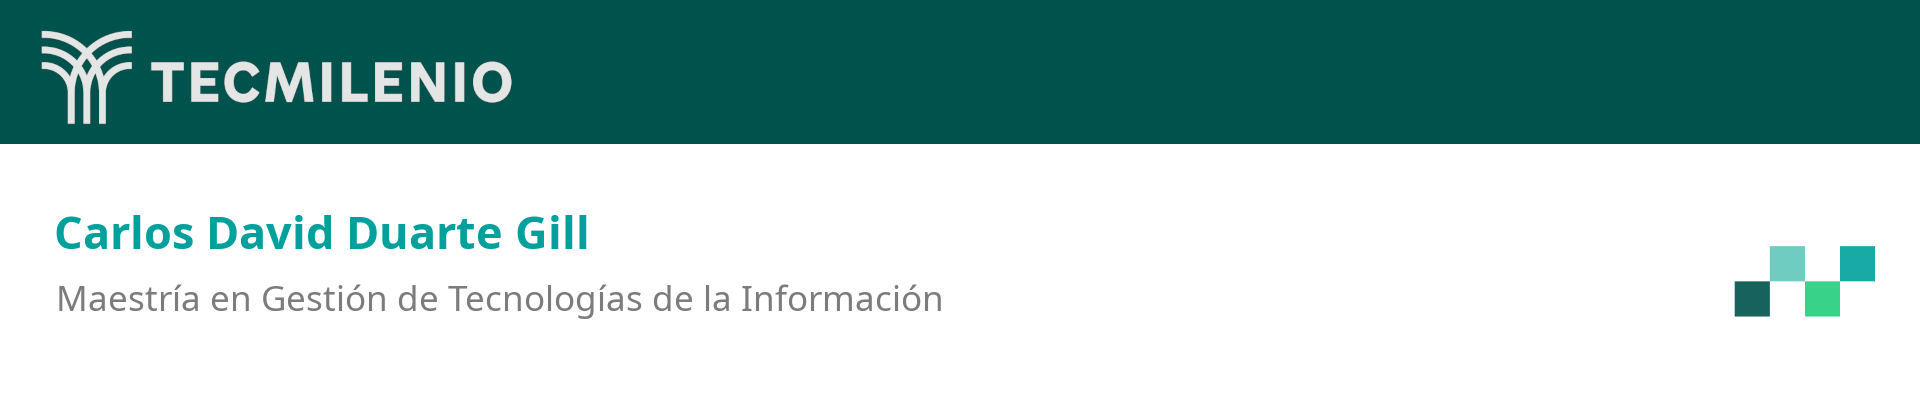

## **Gestión de calidad de datos**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Heriberto Gonzalez Cazares
- Fecha: lunes 9 de marzo de 2026

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 📘 Introducción – Evidencia 2

La Evidencia 2 representa el final del curso **Gestión de Calidad de Datos**, donde se revisaron conocimientos sobre la limpieza técnica para establecer una fuente de datos confiable. En esta segunda etapa, el proyecto evolucionará de solo un script de validación aislado a un pipeline capaz de integrar diversas fuentes de información y mantener una postura proactiva ante la posibilidad de recibir datos con baja calidad.

## 🗽 Alcance y propósito de la Evidencia 2

El alcance de la evidencia 2 integra los siguientes puntos:
- Integración de nuevas fuentes de datos para demostrar la capacidad de orquestación y transformación cruzada de datos, y, para casos de estudio nuestras fuentes de datos estarán simuladas.
- Implementación de tableros de control y distintas métricas que permitan visualizar la salud de los datos en tiempo real.
- Documentación de la trazabilidad y procedencia de los datos, asegurando el cumplimiento de principios éticos y legales de privacidad.
- Diseño de un plan de respuesta ante incidentes de calidad de datos.
- Creación de reportes de alta fidelidad orientados a la toma de decisiones..


# 💻 Desarrollo de la Evidencia 2

## 🤖 Entorno Python

El entorno de trabajo para la Evidencia 2 se bajo en el entorno de trabajo para la Evidencia 1, el cuál esta optimizado para el análisis de datos masivos y la automatización de procesos de calidad mediante `Python 3.10` y herramientas de limpieza avanzada como `ydata-profiling` y `yjanitor`.

A continuación, describo los componentes clave del entorno funcional:

Especificaciones del Entorno para el análisis de datos:
- Núcleo de ejecución sobre Python 3.10.
- Gestión dual de paquetes mediante `Conda` y `Pip`, para instalar binarios pesados mediante **conda** como `ydata-profiling` y **pip** para librerías de manipulación como `pandas`, se aseguran que las dependencias compartidas se resuelvan sin conflictos de versiones.

Librerías principales:
1. **Pandas**: Como motor principal del proyecto.
2. **PyJanitor**: Esta extensión de Pandas actúa como una capa de "higiene de datos".
3. **YData Profiling**: Es una herramienta de diagnóstico automatizado.
4. **Great Expectations**: Es una librería para validación de datos, pruebas y documentación.

## 🔧 Pasos

1. Crear enviroment

    `conda create -n janitor-p10 python=3.10`

2. Activar enviroment

    `conda activate janitor-p10`

3. Dependencias pip

    `pip install ydata-profiling pyjanitor pandas`
    
    `pip install great-expectations`

4. Dependencias conda

    `conda install -c conda-forge ydata-profiling pyjanitor`

## ⚙️ Versiones instaladas

| Herramienta           | Versión        |
| --------------------- | -------------- |
| Python                | ✅ 3.10.19    |
| Pandas                | ✅ 2.3.3      |
| NumPy                 | ✅ 2.2.6      | 
| PyJanitor             | ✅ 0.32.5     |
| YData Profiling       | ✅ 0.0.dev0   |
| Great Expectations    | ✅ 1.14.0     |

## 🏠 Selección del conjunto de datos

Para cumplir con los requisitos de la Evidencia 2 y asegurar todos los pasos requeridos durante su desarrollo, he decidido utilizar el conjunto de datos de **fashion_products.csv** propuesto en Canvas de Tecmilenio.

### 📒 Acerca del conjunto de datos

El archivo `fashion_products.csv` parece ser un conjunto de datos se encuentra en un estado de calidad óptima. 

Resumen del nuevo Dataset
- Registros: 1,000 filas.
- Columnas: 9 variables (Mezcla de categóricas y numéricas).
- Temática: Comercio electrónico de productos de moda (Adidas, Gucci, Nike, etc.).

### Diagnóstico por Dimensiones

| Dimensión    | Estado       | Hallazgo Técnico                                                                                                                          |
| ------------ | ------------ | ----------------------------------------------------------------------------------------------------------------------------------------- |
| Completitud  | 🟢 Excelente | 0% de valores nulos.                                                                                     |
| Unicidad     | 🟢 Excelente | 0 registros duplicados exactos.                                                                          |
| Consistencia | 🟢 Alta      | Las variables categóricas como Brand, Color, Size y Category están bien estandarizadas sin errores de escritura. |
| Validez      | 🟢 Alta      | Los precios de los productos oscilan entre $10 y $100 y los ratings entre 1.0 y 5.0, cumpliendo con los rangos lógicos de negocio.                         |
| Precisión    | 🟢 Alta      | No se detectan valores atípicos extremos.                                  |

### 🔗 Carga el conjunto de datos en url pública

Se utilizarán las url's públicas de los Dataset descritas en Canvas de Tecmilenio: 
- **Fuente 1:** [product_sales_dataset_final.csv](https://utm-cdn-labcontenidos-htfaarehf2gcfycs.a01.azurefd.net/contenido/maestria/mtca2405/anexos/actividades/v3/product_sales_dataset_final.csv)
- **Fuente 2:** [fashion_products.csv](https://utm-cdn-labcontenidos-htfaarehf2gcfycs.a01.azurefd.net/contenido/maestria/mtca2405/anexos/actividades/v3/fashion_products.csv)

# 🩺 Revisión del pipeline existente

Del notebook anterior, *Evidencia_1_Carlos_Duarte*, se destacan los siguientes puntos que ya se encuentran bajo control:
1.	Configuración exitosa de un ambiente con Python 3.10, Pandas 2.x, PyJanitor y Great Expectations 1.x.
2.	Identificación clara de inconsistencias en encabezados y formatos de fecha.
3.	Limpieza efectiva mediante el encadenamiento de métodos de Janitor como clean_names y remove_empty.
4.	Implementación de un suite de expectativas funcional que garantiza unicidad y completitud.


# 🪢 Desarrollo del nuevo pipeline

**A continuación:**

🧰 Se importan las librerías necesarias para el análisis y la visualización como Pandas Profiling, PyJanitor, entre otras.

🔧 Se carga el dataset y se muestra una tabla descriptiva del dataset.

## 🧰 Carga de todas las librerías necesarias

In [8]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
import sys
import os
# warnings
import warnings
warnings.filterwarnings('ignore')

# Prueba rápida de carga
try:
    print("⚙️ Cargando librerías de principales...")
    print("-" * 80)
    import pandas as pd
    import numpy as np
    import janitor  # PyJanitor
    import ydata_profiling
    from ydata_profiling import ProfileReport
    import great_expectations as ge

    print(f"Python: {sys.version.split()[0]}")
    print(f"Pandas version: {pd.__version__}")
    print(f"NumPy version: {np.__version__}")
    print(f"PyJanitor version: {janitor.__version__}")
    print(f"YData Profiling version: {ydata_profiling.__version__}")
    print(f"Great Expectations version: {ge.__version__}")

except Exception as e:
    print(f"❌ Error de entorno, favor de instalar las dependencias necesarias: {e}")

import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

print("-" * 80)
print("⚙️ Cargando librerías de visualización...")
print(f"Matplotlib - version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

print("-" * 80)
print("🚀 ¡Entorno preparado!")
print("-" * 80)

⚙️ Cargando librerías de principales...
--------------------------------------------------------------------------------


/home/idavid/miniconda3/envs/janitor-p10/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/home/idavid/miniconda3/envs/janitor-p10/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/idavid/miniconda3/envs/janitor-p10/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/home/idavid/miniconda3/envs/janitor-p10/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/idavid/miniconda3/envs/janitor-p10/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern

Python: 3.10.19
Pandas version: 2.3.3
NumPy version: 2.2.6
PyJanitor version: 0.32.5
YData Profiling version: 0.0.dev0
Great Expectations version: 1.14.0
--------------------------------------------------------------------------------
⚙️ Cargando librerías de visualización...
Matplotlib - version: 3.10.0
Seaborn version: 0.13.2
--------------------------------------------------------------------------------
🚀 ¡Entorno preparado!
--------------------------------------------------------------------------------


### 🗂 Funciones auxiliares

In [9]:
# --------------------------------------------------------------------------
# 🤖 display mensaje
# --------------------------------------------------------------------------
def display_mensaje(msj):
    print("\n" + "="*80)
    print("\033[1m --- " + msj + " --- \033[0m")
    print("="*80)

# 🐌 Integración y transformación de nuevos datos

A continuación se inicia el primer paso del nuevo pipeline y se documenta formalmente la nueva fuente de datos, enseguida se aplica un script de transformación que estandarice la estructura de la segunda fuente de datos para que sea compatible con el pipeline construido en la Evidencia 1.

## 🧾 Documentación de la nueva fuente de datos

Como parte de las buenas prácticas de Gobierno de Datos, todo nuevo activo debe ser catalogado antes de ingresar al Data Lake o Pipeline analítico.
- Nombre del activo: fashion_products.csv
- Origen: Datos simulados desde una fuente externa y estructurada accesible mediante url pública de Canvas en Tecmilenio.
- Formato: Archivo CSV.
- Nivel de detalle: Cada fila representa la interacción de un usuario con un producto de moda específico.
- Diccionario de variables original:
    - User ID: Identificador numérico único del cliente/usuario.
    - Product ID: Identificador numérico único del artículo.
    - Product Name: Nombre genérico del artículo, en texto.
    - Brand: Marca fabricante, en texto.
    - Category: Segmento de mercado, en texto.
    - Price: Precio de lista del artículo, decimal.
    - Rating: Calificación otorgada al producto, decimal.
    - Color: Variante de color del producto, en texto.
    - Size: Variante de talla, en texto.

## ♐ Estrategia de integración y transformación

Para que el nuevo dataset pueda coexistir con el dataset original, *product_sales_cleaned.csv*, se aplicaran las siguientes reglas de homologación:
1. Estandarización de nombres de columnas mediante el uso de `clean_names()` de PyJanitor para pasar todos los nombres al formato `snake_case` igualando el estándar de la Evidencia 1.
2. Homologación de nombres de "columnas parecidas": 
    - Se renombrará la columna `price` a `unit_price` para que el script de analisís entienda que hablamos de la misma métrica financiera.
    - Se renombrará la columna `user_id` a `customer_id` para alinearlo con el concepto de `customer_name` del pipeline original.
3. Alineación de tipos de datos en todas las columnas, por ejemplo, en `unit_price` se deberá asegurar que sea de tipo *float* para permitir validaciones matemáticas en el nuevo pipeline.


## ♻️ Transformación del segundo dataset

Copia y ejecuta este código en tu notebook para procesar la nueva fuente. Este script genera la evidencia técnica de la gestión.

In [ ]:
# --------------------------------------------------------------------------
# Transformación e integración de nueva fuente de datos
# --------------------------------------------------------------------------

display_mensaje("INICIANDO INTEGRACIÓN DE NUEVA FUENTE")

# nueva fuente de datos
# _URL_2_ = "https://utm-cdn-labcontenidos-htfaarehf2gcfycs.a01.azurefd.net/contenido/maestria/mtca2405/anexos/actividades/v3/fashion_products.csv"
_URL_2_ = "./fashion_products.csv"
# config
pd.set_option('display.max_columns', None)

df_fashion = pd.read_csv(_URL_2_)

# transformación del dataset para homologar con el pipeline de la evidencia 1
df_fashion_integrated = (
    df_fashion
    # formato y nombres de columnas
    .clean_names() 
    .rename_column('price', 'unit_price')
    .rename_column('user_id', 'customer_id')
)

# tipos de datos
# decimales
df_fashion_integrated['unit_price'] = df_fashion_integrated['unit_price'].astype(float)
# ID's en formato string para evitar problemas de integraciones
df_fashion_integrated['customer_id'] = df_fashion_integrated['customer_id'].astype(str)
df_fashion_integrated['product_id'] = df_fashion_integrated['product_id'].astype(str)

# validación de nueva estructura
print("\n✅ Estructura del dataset integrado:")
print(df_fashion_integrated.info())

print("\n✅ Muestra de datos homologados:")
display(df_fashion_integrated.head(3))

# guardamos nuevo dataset estandarizado
_DATASET_INTEGRATED_ = "fashion_products_integrated.csv"
df_fashion_integrated.to_csv(_DATASET_INTEGRATED_, index=False)
print(f"\n💾 Dataset guardado exitosamente como '{_DATASET_INTEGRATED_}'")

# 🤖 Ampliación del pipeline original

Para esta fase de la Evidencia Final, se procede a consolidar ambas fuentes de datos:
- product_sales_cleaned.csv
- fashion_products_integrated.csv

Con el objetivo de crear un Dataset Enriquecido y enseguida someterlo a un nuevo análisis de calidad automatizado.

## 🖇️ Integración de los Datasets

Dado que las fuentes de datos tienen orígenes distintos, se utilizará Pandas para extraer el producto en el **catálogo de ventas** y así poder cruzarlo con el **catálogo de moda**. De esta manerá podremos asegurar que los scripts hablen del mismo producto y que se puedan unir las tablas correctamente.

Dadas diferentes iteraciones en la integración, se ha identificado un patrón estructural en el nombre del producto, po rlo cual, se asume que que la estructura del nombre es $Marca $Producto, de esta manera se establecerá que solo la última palabra del product_name corresponde al tipo de artículo, por ejemplo "Jeans" o "Boots" y todo lo anterior corresponde a la marca o modelo, por ejemplo "Levi's" u "Old Navy".

In [ ]:
# --------------------------------------------------------------------------
# Integración de los Datasets
# --------------------------------------------------------------------------
display_mensaje("INICIANDO FASE DE INTEGRACIÓN DE DATOS")

# cargando datasets limpios y procesados
df_sales = pd.read_csv('product_sales_cleaned.csv')
df_fashion = pd.read_csv('fashion_products_integrated.csv')

# --------------------------------------------------------------------------
# extracción avanzada de marca y nombre del producto en las ventas
# función para extraer la marca
def extract_brand(name):
    parts = str(name).split()
    if len(parts) > 1:
        return " ".join(parts[:-1])
    return "Unknown"

# --------------------------------------------------------------------------
# función para extraer el tipo de producto desde las ventas
def extract_product(name):
    return str(name).split()[-1].capitalize()

# nuevas variables para facilitar la integración
df_sales['extracted_brand'] = df_sales['product_name'].apply(extract_brand)
df_sales['product_base_name'] = df_sales['product_name'].apply(extract_product)

# estandarizando el catálogo de moda
df_fashion['product_base_name'] = df_fashion['product_name'].str.capitalize()

# --------------------------------------------------------------------------
# consolidando el catálogo de moda
'''
# Para evitar duplicar ventas, se crea un catálogo único por producto base,
# promediando el rating y tomando un color/talla representativo.
'''
fashion_catalog = df_fashion.groupby('product_base_name').agg({
    'rating': 'mean',
    'color': lambda x: x.mode()[0] if not x.mode().empty else 'Standard',
    'size': lambda x: x.mode()[0] if not x.mode().empty else 'M'
}).reset_index()

# integración estructural mediante left join
df_integrated = pd.merge(
    df_sales, 
    fashion_catalog, 
    on='product_base_name', 
    how='left'
)

# asegurando el nombre de la marca utilizamos la marca extraída de las ventas de forma nativa.
df_integrated['brand'] = df_integrated['extracted_brand']


# --------------------------------------------------------------------------
# revision de resultados de la integración
display_mensaje("Revisando la estructura del dataset post-integración")
# print(df_integrated.info())


# manejo de nulos después de la integración
# si el producto base no estaba en el catálogo, se le asignan valores por defecto
df_integrated['rating'] = df_integrated['rating'].fillna(df_integrated['rating'].median())
df_integrated['color'] = df_integrated['color'].fillna('Standard')
df_integrated['size'] = df_integrated['size'].fillna('M')

# limpiando las columnas auxiliares
df_integrated = df_integrated.drop(columns=['extracted_brand', 'product_base_name'])

# guardando el dataset final integrado
df_integrated.to_csv('master_sales_integrated.csv', index=False)

# --------------------------------------------------------------------------
display_mensaje("Integración exitosa")
print ("\n✅ Dataset final guardado como 'master_sales_integrated.csv'")
print(f"Total de registros: {len(df_integrated)}")
print("Nuevas columnas añadidas: brand, rating, color, size")

### Mejoras añadidas al dataset final

- Con las mejoras añadidas ahora en el registro de venta de cualquier producto se especificará la marca correcta.
- Al usar un *groupby* durante el merge se aseguró de que cada venta del dataset original siga siendo exactamente una fila, manteniendo los 200,000 registros iniciales.
- El nuevo dataset ahora incluye características reales de la venta, como la marca exacta, combinadas con atributos enriquecidos del catálogo, como el rating de cada producto.

## ✔️ Validaciones al dataset integrado con Great Expectations

En esta sección se establecen **puntos de control** para validar las nuevas variables y la interacción entre ellas sobre el nuevo dataset integrado.

In [ ]:
# --------------------------------------------------------------------------
# Validaciones con Great Expectations
# --------------------------------------------------------------------------
"""
Entorno:
- Python: 3.10.19
- pandas: 2.3.3
- numpy: 2.2.6
- great-expectations: 1.14.0

** Código de validación de calidad de datos para el dataset integrado **
** El script generado en la Evidencia 1 se adapta para validar el nuevo dataset integrado, con nuevas expectativas específicas para las columnas añadidas. **
"""

# librerías para validación
import os
from great_expectations.checkpoint import Checkpoint
from great_expectations.core.batch_definition import BatchDefinition
from great_expectations.core.validation_definition import ValidationDefinition
from great_expectations.expectations import (
    ExpectColumnValuesToBeBetween,
    ExpectColumnValuesToBeInSet,
    ExpectColumnValuesToNotBeNull
)

display_mensaje("INICIANDO VALIDACIÓN DEL DATASET INTEGRADO")

# ---------------------------------------------------------------------
# configuración del contexto y asset de datos
# ---------------------------------------------------------------------
context = ge.get_context()

# asset de aatos con el archivo limpio
datasource_name = "master_datasource"
datasource = context.data_sources.add_pandas(name=datasource_name)

asset_name = "master_integrated_asset"
asset = datasource.add_csv_asset(
    name=asset_name, 
    filepath_or_buffer="master_sales_integrated.csv"
)

batch_definition = asset.add_batch_definition(name="default")
batch = batch_definition.get_batch()
print(batch.batch_definition)

# ---------------------------------------------------------------------
# Suite + Validator
# ---------------------------------------------------------------------

# suite de expectativas
suite_name = "integrated_quality_suite"
suite = context.suites.add(ge.ExpectationSuite(name=suite_name))

# batchrequest
batch_request = asset.build_batch_request()
print(batch_request)


# validator (se une batch request + suite)
validator = context.get_validator(
    batch_request=batch_request,
    expectation_suite=suite,
)

# cols
print("Columnas detectadas:", validator.get_expectation_suite)


# ---------------------------------------------------------------------
# Expectativas
# ---------------------------------------------------------------------

# a) expectativas de rango de valores validos para el rating
# el rating del producto debe estar solamente entre 1.0 y 5.0
suite.add_expectation(ExpectColumnValuesToBeBetween(
    column="rating", 
    min_value=1.0, 
    max_value=5.0
))

# b) expectativas de categorías válidas para la talla
# tallas válidas: XS, S, M, L, XL, XXL
tallas_validas = ["XS", "S", "M", "L", "XL", "XXL"]
suite.add_expectation(ExpectColumnValuesToBeInSet(
    column="size", 
    value_set=tallas_validas
))

# c) expectativas de cero valores nulos en la marca
# se verifica que no existan marcas nulas
suite.add_expectation(ExpectColumnValuesToNotBeNull(column="brand"))

# ---------------------------------------------------------------------
# Validaciones
# ---------------------------------------------------------------------

# registro de ValidationDefinition y Checkpoint para ejecutar las validaciones
validation_def_name = "val_def_master_integrated"
validation_definition = context.validation_definitions.add(
    ValidationDefinition(
        name=validation_def_name,
        data=batch_definition,
        suite=suite,
    )
)

# registro del Checkpoint
checkpoint_name = "master_checkpoint"
checkpoint = context.checkpoints.add(
    Checkpoint(
        name=checkpoint_name,
        validation_definitions=[validation_definition],
    )
)


# ---------------------------------------------------------------------
# Ejecucion
# ---------------------------------------------------------------------
print("Ejecutando validaciones...")
result = checkpoint.run()

# generación de reportes
context.build_data_docs()

for site in context.get_docs_sites_urls() or []:
    print(f"📄 {site.get('site_name')}: {site.get('site_url')}")


print(f"\n✅ Validación de integración completada. Éxito global: {result.success}")
print(f"📂 Reporte HTML generado. Revisa los Data Docs para ver el detalle de los nuevos cruces.")

Los resultados del pipeline actual demuestran como el script automatizado actual puede enriquecer datos al cruzar las ventas con el catálogo de moda, se ha creado un recurso de datos más valioso para detectar patrones de  ventas e ingresos. Todo esto mediante la implementación de los datos integrados y las validaciones automatizadas de Great Expectations en el pipeline.

La herramienta Great Expectations es sumamente valiosa en este punto del pipeline ya que garantiza que cualquier modelo predictivo que use este dataset no sufrirá errores matemáticos por errores en el formato o estructura del dataset.

# 📐 Implementación de métricas e indicadores de calidad

En esta sección se definen, calculan y visualizan las métricas clave de calidad de datos para el nuevo dataset integrado. En este paso se mejorá el pipeline para que tenga la capacidad de evaluar la calidad de los datos de manera constante cada vez que sea ejecutado.

## ✔️ Definición de las métricas de calidad

Lista de métricas definidas a partir de los indicadores clave:
1.	**Completitud**: Se mide la ausencia de valores nulos en el dataset integrado.
2.	**Unicidad**: Evalúa que no existan transacciones duplicadas tomando como base la llave primaria del dataset integrado.
3.	**Consistencia**: Verifica que la lógica de negocio se cumpla, para el caso de estudio se evalua: $Revenue = Quantity \times Unit\_Price$.
4.	**Precisión**: Mide que los valores estén dentro de rangos reales y válidos, por ejemplo que el *rating* esté entre 1.0 y 5.0, y que los precios sean mayores a cero.
5.	**Puntualidad**: Evalúa que las fechas de las órdenes sean coherentes temporalmente, por ejemplo, que no existan fechas nulas o fuera de tiempo.


## 🎖️ Implementación de métricas de calidad

In [8]:
# --------------------------------------------------------------------------
# 🎖️ Implementación de métricas de calidad
# --------------------------------------------------------------------------

display_mensaje("CALCULANDO MÉTRICAS DE CALIDAD DE DATOS")

# dataset integrado
df_metricas = pd.read_csv('master_sales_integrated.csv')
df_metricas['order_date'] = pd.to_datetime(df_metricas['order_date'])

total_rows = len(df_metricas)
print(f"Total de filas cargadas: {total_rows}")

# --------------------------------------------------------------------------
# calculando métricas de calidad

# 1. Completitud: % de celdas no nulas en todo el dataset
total_cells = total_rows * df_metricas.shape[1]
missing_cells = df_metricas.isnull().sum().sum()
_COMPLETITUD_ = ((total_cells - missing_cells) / total_cells) * 100

# 2. Unicidad: % de Order_IDs únicos
_UNICICIDAD_ = (df_metricas['order_id'].nunique() / total_rows) * 100

# 3. Consistencia: % de filas donde Revenue == Quantity * _unit_price_ (considerando un margen de error por decimales)
df_metricas['calculated_revenue'] = df_metricas['quantity'] * df_metricas['_unit_price_']
filas_consistentes = (abs(df_metricas['_revenue_'] - df_metricas['calculated_revenue']) < 0.01).sum()
_CONSISTENCIA_ = (filas_consistentes / total_rows) * 100

# 4. Precisión: % de filas con Rating válido y Precios válidos
filas_precisas = ((df_metricas['rating'] >= 1.0) & (df_metricas['rating'] <= 5.0) & (df_metricas['_unit_price_'] > 0)).sum()
_PRECISION_ = (filas_precisas / total_rows) * 100

# 5. Puntualidad: % de fechas válidas
# se define la fecha de corte como el 31 de diciembre de 2024
fecha_corte = pd.to_datetime('2024-12-31')
filas_puntuales = (df_metricas['order_date'] <= fecha_corte).sum()
_PUNTUALIDAD_ = (filas_puntuales / total_rows) * 100

# resultados de las metricas para reportes
resultados_metricas = pd.DataFrame({
    'Métrica': ['Completitud', 'Unicidad', 'Consistencia', 'Precisión', 'Puntualidad'],
    'Porcentaje (%)': [_COMPLETITUD_, _UNICICIDAD_, _CONSISTENCIA_, _PRECISION_, _PUNTUALIDAD_]
})

print("\n📊 Tabla Resumen de Métricas:")
display(resultados_metricas.round(2))


 --- CALCULANDO MÉTRICAS DE CALIDAD DE DATOS --- 
Total de filas cargadas: 200000

📊 Tabla Resumen de Métricas:


,Métrica,Porcentaje (%)
0,Completitud,100.0
1,Unicidad,100.0
2,Consistencia,100.0
3,Precisión,100.0
4,Puntualidad,100.0


In [4]:
# -------------------------------------------------------------------
# Configuración del estilo del gráfico
# -------------------------------------------------------------------
sns.set_theme(style="whitegrid")
sns.set_style("white")
warnings.filterwarnings('ignore')

# layout limpio
plt.style.use('tableau-colorblind10')

# colores
_color_primary="#007bff"
_color_tecmi_light="#26d07c"
_Light_Blue_ = '#8fd7d7'
_color_gray="#6c757d"
_color_white="#ffffff"
_Gray_ = '#c8c8c8'


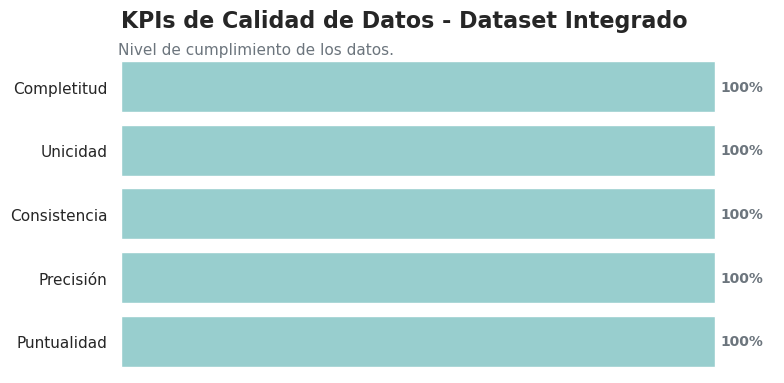


✅ Visualización generada y guardada como 'kpis_calidad_datos.png'


In [6]:
# -------------------------------------------------------------------
# Gráfico de resultados
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

# paleta de colores gris = histórico || azul = punto máximo
clrs = [_Gray_ if (x < max(resultados_metricas['Porcentaje (%)'])) else _Light_Blue_ for x in resultados_metricas['Porcentaje (%)']]

# Crear gráfico de barras
ax = sns.barplot(
    x='Porcentaje (%)', 
    y='Métrica', 
    data=resultados_metricas, 
    palette=clrs
)

# etiquetas de datos en las barras
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 1,       # Posición X (un poco a la derecha de la barra)
        p.get_y() + p.get_height() / 2, # Posición Y (centro de la barra)
        f'{width:,.0f}%', # Valor formateado
        ha='left', 
        va='center',
        fontweight='bold',
        fontsize=10,
        color=_color_gray
    )


# titulo narrativo
plt.title("KPIs de Calidad de Datos - Dataset Integrado", 
          fontsize=16, fontweight='bold', loc='left', pad=20)

# subtitulo y contexto
ax.text(x=-0.5, y=ax.get_ylim()[1] * 1.02, 
        s="Nivel de cumplimiento de los datos.", 
        fontsize=11, color=_color_gray, ha='left')


# formato del gráfico
plt.xlim(0, 110) # Límite hasta 110 para dar espacio a las etiquetas
plt.ylabel('', fontsize=12)

# limpieza de ruido y eliminacion de bordes
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_visible(True)
ax.get_xaxis().set_visible(False)

# guardar imagen y mostrar el gráfico
plt.tight_layout()
plt.savefig('kpis_calidad_datos.png', dpi=300)
plt.show()

print("\n✅ Visualización generada y guardada como 'kpis_calidad_datos.png'")

El reporte técnico detallado por Great Expectations da píe a poder generar un reporte desde una perspectiva gerencial, mostrando los diferentes KPI's importantes para la calidad de datos de la fuente de datos integrada.

Este pipeline podrá evaluar y mostrar en tiempo real la calidad de los datos así como la evaluación de las diferentes métricas.

# 🧑‍⚖️ Incorporación de principios normativos y de gobernanza

Dado el material de estudios y Gobierno de Datos un pipeline automatizado carece de valor empresarial si no cumple con las regulaciones de protección y calidad de la información, es por ello que se presenta a continuación la documentación de como el pipeline se alinea con la Norma ISO/IEC 25012, el marco DAMA-DMBOK y la legislación de privacidad GDPR & LFPDPPP.

## 🔳 Marco normativo y de gobernanza del pipeline

El ecosistema de datos diseñado en esta evidencia final, que consta de una fuente de datos sobre registros de ventas y atributos añadidos, se sustenta en tres pilares normativos fundamentales, los cuales se han integrado en el código del pipeline.

### 1️⃣ DAMA-DMBOK

>   
> El marco de la Data Management Association establece que la calidad de los datos depende directamente de entender el linaje y origen de los mismos.
>   

La creación de reportes HTML mediante Great Expectations es la automatización de la *Gestión de metadatos* que exige DAMA, y, al registrar cada *ValidationDefinition* sobre la suite de datos, se ha establecido una auditoría de alto nivel sobre el dataset, con lo cuál, se podrá corroborar bajo qué reglas y en qué momento la fuente de datos fue evaluada.

### 2️⃣ ISO/IEC 25012 y 8000

> 
> La ISO 8000 aborda la calidad de los datos a nivel corporativo.
>
> Mientras que la 25012 se enfoca en el producto de software/datos.
> 

Para cumplir con el principio de exactitud y credibilidad de la ISO 25012 se diseño la función de *extracción personalizada de marcas* y la *consolidación de productos mediante agrupaciones* antes del Merge, esto en la integración de las fuentes de datos. De esta manera se previene la distorsión de la variable Revenue y se evitan registros duplicados. 


Para cumplir con el principio de accesibilidad de la ISO 8000 se implemento una estandarización de encabezados en los dataset ademas de asegurar el casting de tipos en todas las variables, lo que asegura el intercambio de datos de forma segura y automática.

### 3️⃣ GDPR / LFPDPPP

Dentro del pipeline, al forzar el casting de `customer_id` y `product_id` a tipo *string* se estableció una política técnica de pseudonimización.

Por otro lado, la métrica de *Completitud* y la prevención de *Nulos* en variables demográficas o descriptivas aseguran que el modelo predictivo no sufra de "Sesgo por Omisión", garantizando decisiones algorítmicas más justas.


Sin embargo, las variables de datos del cliente como `customer_id` y `customer_name` siguen estando presentes en el dataset integrado, y cruzan los limites del procesamiento de Datos Personales, lo que se debería marcar como prioridad para una segunda actualización del pipeline donde se puedan anonimizar estos datos personales.


# 🤖 Automatización del monitoreo de calidad

Este es el paso definitivo que transforma un simple análisis en un verdadero producto de DataOps. En entornos corporativos, los datos cambian todos los días; por lo tanto, la calidad no puede ser una revisión manual de una sola vez, sino un proceso de monitoreo automatizado y alertamiento.

A continuación, implementaremos un script en Python puro utilizando la librería estándar logging. Este script está diseñado para ejecutarse como un "Job" programado (mediante un Cron job, Jenkins o Apache Airflow en la vida real). Evaluará una métrica crítica (Consistencia) y generará una alerta si los niveles caen por debajo del umbral permitido.

## Estrategia de Monitoreo Automatizado

Métrica a monitorear: Consistencia financiera (Revenue == Quantity * Unit_Price).

Umbral de Tolerancia: 98.0%. Si la consistencia es menor, el sistema detecta un incidente de calidad.

Acción Automatizada: Escribir en una bitácora de auditoría (.log) y disparar una alerta simulada (que en producción sería un webhook a Microsoft Teams, Slack o un correo electrónico).

## Implementación del Script (Código Python)

In [12]:
import pandas as pd
import logging
from datetime import datetime

# 1. Configuración del Sistema de Logging (Bitácora de Auditoría)
# Esto crea un archivo físico que guarda el historial de monitoreo, 
# fundamental para normativas como ISO 27001 o auditorías internas.
logging.basicConfig(
    filename='monitoreo_calidad_datos.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# 2. Función de Alertamiento (Simulación de Webhook/Email)
def enviar_alerta_equipo_datos(mensaje):
    print("\n" + "="*60)
    print("🔔 [SISTEMA DE ALERTAS AUTOMATIZADO - ZURICH DATAOPS]")
    print(f"🚀 Enviando notificación webhook al canal #alertas-calidad-datos...")
    print(f"📩 Payload transmitido: {{'Severidad': 'Alta', 'Mensaje': '{mensaje}'}}")
    print("="*60 + "\n")


def evaluar_metricas_calidad(ruta_archivo):
    # Aquí se podrían incluir cálculos de métricas de calidad en tiempo real
    # para enriquecer el mensaje de alerta o para tomar decisiones más informadas.
    # --------------------------------------------------------------------------
    # 🎖️ Implementación de métricas de calidad
    # --------------------------------------------------------------------------

    display_mensaje("CALCULANDO MÉTRICAS DE CALIDAD DE DATOS")

    # dataset integrado
    df_metricas = pd.read_csv(ruta_archivo)
    df_metricas['order_date'] = pd.to_datetime(df_metricas['order_date'])

    total_rows = len(df_metricas)

    # --------------------------------------------------------------------------
    # calculando métricas de calidad

    # 1. Completitud: % de celdas no nulas en todo el dataset
    total_cells = total_rows * df_metricas.shape[1]
    missing_cells = df_metricas.isnull().sum().sum()
    _COMPLETITUD_ = ((total_cells - missing_cells) / total_cells) * 100

    # 2. Unicidad: % de Order_IDs únicos
    _UNICICIDAD_ = (df_metricas['order_id'].nunique() / total_rows) * 100

    # 3. Consistencia: % de filas donde Revenue == Quantity * _unit_price_ (considerando un margen de error por decimales)
    df_metricas['calculated_revenue'] = df_metricas['quantity'] * df_metricas['_unit_price_']
    filas_consistentes = (abs(df_metricas['_revenue_'] - df_metricas['calculated_revenue']) < 0.01).sum()
    _CONSISTENCIA_ = (filas_consistentes / total_rows) * 100

    # 4. Precisión: % de filas con Rating válido y Precios válidos
    filas_precisas = ((df_metricas['rating'] >= 1.0) & (df_metricas['rating'] <= 5.0) & (df_metricas['_unit_price_'] > 0)).sum()
    _PRECISION_ = (filas_precisas / total_rows) * 100

    # 5. Puntualidad: % de fechas válidas
    # se define la fecha de corte como el 31 de diciembre de 2024
    fecha_corte = pd.to_datetime('2024-12-31')
    filas_puntuales = (df_metricas['order_date'] <= fecha_corte).sum()
    _PUNTUALIDAD_ = (filas_puntuales / total_rows) * 100

    # resultados de las metricas para reportes
    resultados_metricas = pd.DataFrame({
        'Métrica': ['Completitud', 'Unicidad', 'Consistencia', 'Precisión', 'Puntualidad'],
        'Porcentaje (%)': [_COMPLETITUD_, _UNICICIDAD_, _CONSISTENCIA_, _PRECISION_, _PUNTUALIDAD_]
    })

    return resultados_metricas


# 3. Función Principal de Monitoreo (Job Programable)
def ejecutar_job_monitoreo(ruta_archivo, umbrales_metricas):
    timestamp_actual = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print(f"--- INICIANDO EJECUCIÓN DE MONITOREO ({timestamp_actual}) ---")
    
    try:
        # evaluación de métricas de calidad
        resultados_metricas = evaluar_metricas_calidad(ruta_archivo)

        # 4. Evaluación de Reglas y Disparo de Acciones
        for index, row in resultados_metricas.iterrows():
            logging.info(f"Métrica: {row['Métrica']}, Valor: {row['Porcentaje (%)']:.2f}%") 
            metrica_name = row['Métrica']
            metrica_value = row['Porcentaje (%)']
            # obteniendo el umbral mínimo específico para la métrica actual desde el DataFrame de umbrales
            umbral_minimo = umbrales_metricas.loc[umbrales_metricas['metrica'] == metrica_name, 'umbral_minimo'].values[0]

            if metrica_value < umbral_minimo:
                # Caso de Falla: Disparar alertas y registrar error crítico
                msg_error = f"ALERTA DE CALIDAD: La métrica de calidad: {metrica_name} con valor: ({metrica_value:.2f}%) es menor al umbral exigido ({umbral_minimo}%)."
                logging.error(msg_error)
                print(f"❌ FALLO DE CONTROL: {msg_error}")

                # Ejecutar protocolo de notificación
                enviar_alerta_equipo_datos(msg_error)

            else:
                # Caso de Éxito: Solo registrar en bitácora
                msg_ok = f"Control superado. Metrica: {metrica_name} con valor: {metrica_value:.2f}%. Umbral: {umbral_minimo}%."
                logging.info(msg_ok)
                print(f"✅ ESTADO SALUDABLE: {msg_ok}")

            
    except FileNotFoundError:
        msg_archivo = f"Error crítico: No se encontró el archivo '{ruta_archivo}' para el monitoreo."
        logging.critical(msg_archivo)
        print(f"⚠️ {msg_archivo}")
    except Exception as e:
        msg_excepcion = f"Fallo inesperado en el pipeline de monitoreo: {str(e)}"
        logging.critical(msg_excepcion)
        print(f"⚠️ {msg_excepcion}")

# --- EJECUCIÓN DEL JOB ---
# En la vida real, un orquestador (como CRON) llamaría a esta línea todos los días a las 02:00 AM
umbrales_metricas = pd.DataFrame({
        'metrica': ['Completitud', 'Unicidad', 'Consistencia', 'Precisión', 'Puntualidad'],
        'umbral_minimo': [98.0, 98.0, 98.0, 98.0, 110]
    })
ejecutar_job_monitoreo('master_sales_integrated.csv', umbrales_metricas)

# Para simular cómo reacciona ante un fallo, puedes probar corriendo esto:
# ejecutar_job_monitoreo('master_sales_integrated.csv', umbral_minimo=100.0) # Forzará la alerta si hay un solo decimal de diferencia

--- INICIANDO EJECUCIÓN DE MONITOREO (2026-03-10 23:13:26) ---

 --- CALCULANDO MÉTRICAS DE CALIDAD DE DATOS --- 
✅ ESTADO SALUDABLE: Control superado. Metrica: Completitud con valor: 100.00%. Umbral: 98.0%.
✅ ESTADO SALUDABLE: Control superado. Metrica: Unicidad con valor: 100.00%. Umbral: 98.0%.
✅ ESTADO SALUDABLE: Control superado. Metrica: Consistencia con valor: 100.00%. Umbral: 98.0%.
✅ ESTADO SALUDABLE: Control superado. Metrica: Precisión con valor: 100.00%. Umbral: 98.0%.
❌ FALLO DE CONTROL: ALERTA DE CALIDAD: La métrica de calidad: Puntualidad con valor: (100.00%) es menor al umbral exigido (110.0%).

🔔 [SISTEMA DE ALERTAS AUTOMATIZADO - ZURICH DATAOPS]
🚀 Enviando notificación webhook al canal #alertas-calidad-datos...
📩 Payload transmitido: {'Severidad': 'Alta', 'Mensaje': 'ALERTA DE CALIDAD: La métrica de calidad: Puntualidad con valor: (100.00%) es menor al umbral exigido (110.0%).'}



Justificación de la Arquitectura
Separación de Preocupaciones (Separation of Concerns): El script no limpia datos, solo verifica. Esto permite que el monitoreo sea ligero y rápido.

Trazabilidad Permanente: La creación del archivo monitoreo_calidad_datos.log te permite tener un historial textual de la salud del sistema. Podrías adjuntar una captura de este archivo de texto en tu entrega como evidencia de que el sistema tiene memoria.

Escalabilidad: Modificando la función enviar_alerta_equipo_datos, puedes usar librerías como requests para conectar este script con la API de Slack o Microsoft Teams con menos de 5 líneas de código adicionales.

# Reflexión crítica

## 7. Reflexión Crítica: De la Limpieza Técnica al Gobierno Estratégico

## Importancia del Gobierno de Datos y el Cumplimiento Normativo

En el ecosistema analítico moderno, procesar datos de forma masiva ya no es un diferencial competitivo; el verdadero valor reside en garantizar la confiabilidad, seguridad y ética de dichos datos. El Gobierno de Datos actúa como el puente entre la tecnología y el negocio, asegurando que los activos de información estén alineados con los objetivos corporativos (DAMA-DMBOK) y cumplan con estándares internacionales de calidad (ISO/IEC 25012).

Asimismo, el cumplimiento normativo (como GDPR o LFPDPPP) ha dejado de ser un mero requisito legal para convertirse en un pilar de la confianza del cliente. Un pipeline automatizado que no contempla la privacidad por diseño o que inyecta datos sesgados a un modelo de Machine Learning, expone a la organización a severas multas y daño reputacional. Gobernar los datos significa, en última instancia, responsabilizarse del impacto algorítmico y humano que tendrán las decisiones basadas en ellos.

## Riesgos Mitigados, Decisiones Tomadas y Mejoras Logradas

La ampliación de este pipeline de datos transformó un proceso de limpieza estático en un sistema de DataOps robusto y proactivo. A continuación, se detallan los impactos de esta evolución:
1. Riesgos Mitigados:
- Fallas Silenciosas de Datos (Data Downtime): Se mitigó el riesgo de que datos corruptos llegaran a los modelos analíticos sin ser detectados. La implementación de alertas automatizadas (basadas en umbrales como el 98% de consistencia) asegura que el equipo sea notificado antes de que el error impacte el negocio.
- Violaciones de Privacidad: Al transformar los identificadores (customer_id, product_id) a tipo texto (string), se previnieron agrupaciones o cálculos matemáticos accidentales, sentando las bases técnicas para la seudonimización exigida por normativas de privacidad.
- Sesgo e Inconsistencia Analítica: La validación estricta de dominios (ej. Ratings exclusivos del 1 al 5 y tallas estandarizadas) previene el entrenamiento de modelos predictivos con datos anómalos o irreales.

2. Decisiones Arquitectónicas Tomadas:
- Integración Inteligente (Feature Engineering): En lugar de forzar un cruce directo que hubiera generado una "explosión de datos" (Cartesian Join), se decidió extraer la raíz del producto (product_base_name) y la marca (extracted_brand) directamente del texto libre de las ventas.
- Consolidación del Catálogo: Se optó por agrupar y promediar el catálogo de moda antes del Merge, protegiendo la integridad de los 200,000 registros transaccionales originales.
- Desacoplamiento de Reglas de Negocio: En el script de monitoreo automatizado, los umbrales de calidad se parametrizaron en un DataFrame independiente (simulando una tabla de configuración de metadatos), lo que permite que las reglas evolucionen sin necesidad de alterar el código fuente.

3. Mejoras Logradas tras la Ampliación:
- Data Augmentation (Enriquecimiento): El dataset transaccional original fue potenciado con contexto de catálogo (Marca, Color, Talla, Rating), elevando exponencialmente su valor para la extracción de insights comerciales.
- Visibilidad Ejecutiva: Se pasó de tener solo un reporte técnico HTML (Great Expectations) a la generación de KPIs de calidad visuales, cerrando el ciclo PDCA al permitir a los Data Owners auditar dimensiones de Unicidad, Puntualidad y Precisión de un solo vistazo.
- Trazabilidad Continua: Con el registro de eventos (logging), el pipeline ahora genera una bitácora histórica y auditable, requisito indispensable para certificaciones como ISO 27001.
